# 6주차_데이터 전처리와 파생변수 생성 Ⅰ

- 결측값 처리

---

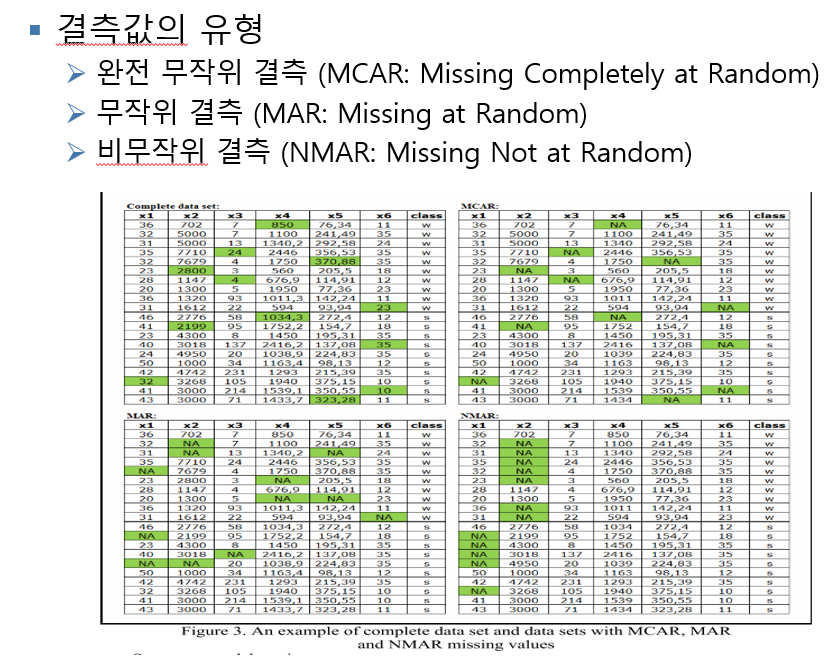

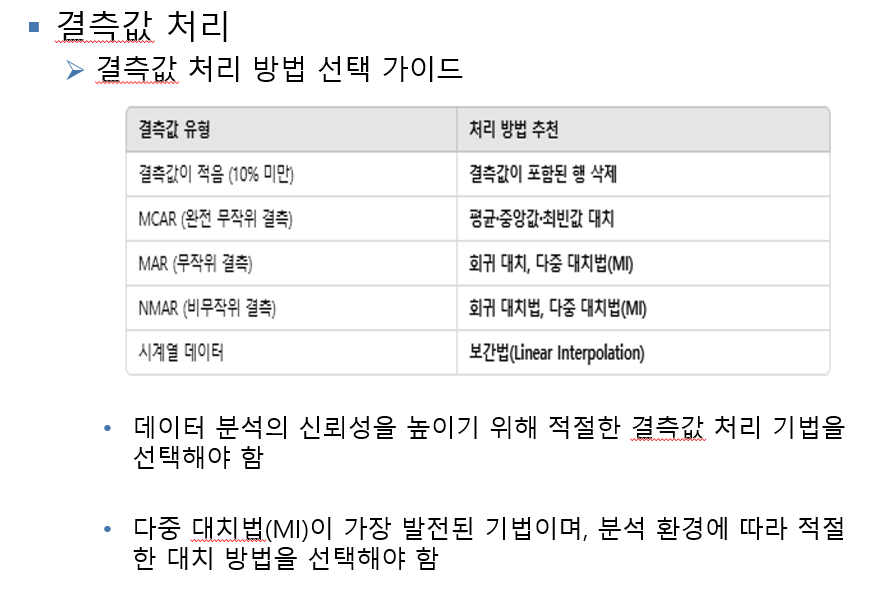

In [13]:
# 필요한 패키지 설치
# !pip install missingno
# missingno는 결측값 시각화를 위한 외부 패키지이므로 처음 실행 시 설치 필요함
# 주석 처리된 상태에서는 실행되지 않음 (필요 시만 해제하여 사용함)

import missingno as msno
# missingno는 결측값(missing values)을 직관적으로 시각화할 수 있는 파이썬 전용 라이브러리임
# 데이터 누락 패턴, 결측 비율, 상관관계 등을 한눈에 파악할 수 있음

from sklearn.experimental import enable_iterative_imputer
# IterativeImputer는 실험적 기능이므로 해당 모듈을 먼저 enable하여 사용할 수 있도록 설정함

from sklearn.impute import IterativeImputer
# IterativeImputer는 다중 대치(MICE: Multivariate Imputation by Chained Equations)를 수행하는 클래스임
# 변수 간 상관관계를 기반으로 결측값을 반복적으로 예측 및 채움

import matplotlib.pyplot as plt
# 데이터 시각화를 위한 matplotlib의 기본 플로팅 모듈을 불러옴

import pandas as pd
# 데이터프레임 생성 및 처리 기능을 제공하는 pandas 라이브러리를 불러옴

import numpy as np
# 수치 연산 및 배열 계산을 위한 numpy 라이브러리를 불러옴

plt.rcParams['figure.dpi'] = 300
# matplotlib의 출력 그래프 해상도를 300DPI로 설정함
# 고해상도의 그래프를 출력하여 시각적 선명도를 높임


In [14]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/sewonghwang/daily-bike-sharing
df = pd.read_csv("../../main/datasets/bike_sharing_daily.csv")

# 데이터 샘플 확인
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131.0,670.0,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,NaN,0.437273,0.248309,120.0,1229.0,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108.0,1454.0,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82.0,1518.0,1600


In [15]:
# 각 컬럼의 속성 및 결측값 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        714 non-null    float64
 10  atemp       707 non-null    float64
 11  hum         706 non-null    float64
 12  windspeed   718 non-null    float64
 13  casual      720 non-null    float64
 14  registered  720 non-null    float64
 15  cnt         731 non-null    int64  
dtypes: float64(6), int64(9), object(1)
memory usage: 91.5+ KB


In [16]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,714.000000,707.000000,706.000000,718.000000,720.000000,720.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.497644,0.474674,0.628691,0.191136,848.102778,3658.512500,4505.255814
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.182952,0.162837,0.142652,0.077166,686.293614,1554.760481,1935.491354
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.341667,0.337842,0.522708,0.135111,314.750000,2499.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.502989,0.482942,0.630000,0.181598,717.000000,3660.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.656667,0.610803,0.731042,0.234156,1095.500000,4753.250000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [17]:
# 각 컬럼의 왜도 확인
df.select_dtypes(include='number').skew()

instant       0.000000
season       -0.000384
yr           -0.002742
mnth         -0.008149
holiday       5.654224
weekday       0.002742
workingday   -0.793147
weathersit    0.957385
temp         -0.069778
atemp        -0.132665
hum          -0.080615
windspeed     0.667473
casual        1.264252
registered    0.051406
cnt          -0.043808
dtype: float64

In [18]:
# 각 컬럼의 첨도 확인
df.select_dtypes(include='number').kurtosis()

instant       -1.200000
season        -1.342601
yr            -2.005487
mnth          -1.209112
holiday       30.052462
weekday       -1.254282
workingday    -1.374686
weathersit    -0.136467
temp          -1.107498
atemp         -0.980769
hum           -0.039245
windspeed      0.406159
casual         1.325395
registered    -0.708637
cnt           -0.816982
dtype: float64

In [19]:
# 결측값 수만 확인
df.isnull().sum()

instant        0
dteday         0
season         0
yr             0
mnth           0
holiday        0
weekday        0
workingday     0
weathersit     0
temp          17
atemp         24
hum           25
windspeed     13
casual        11
registered    11
cnt            0
dtype: int64

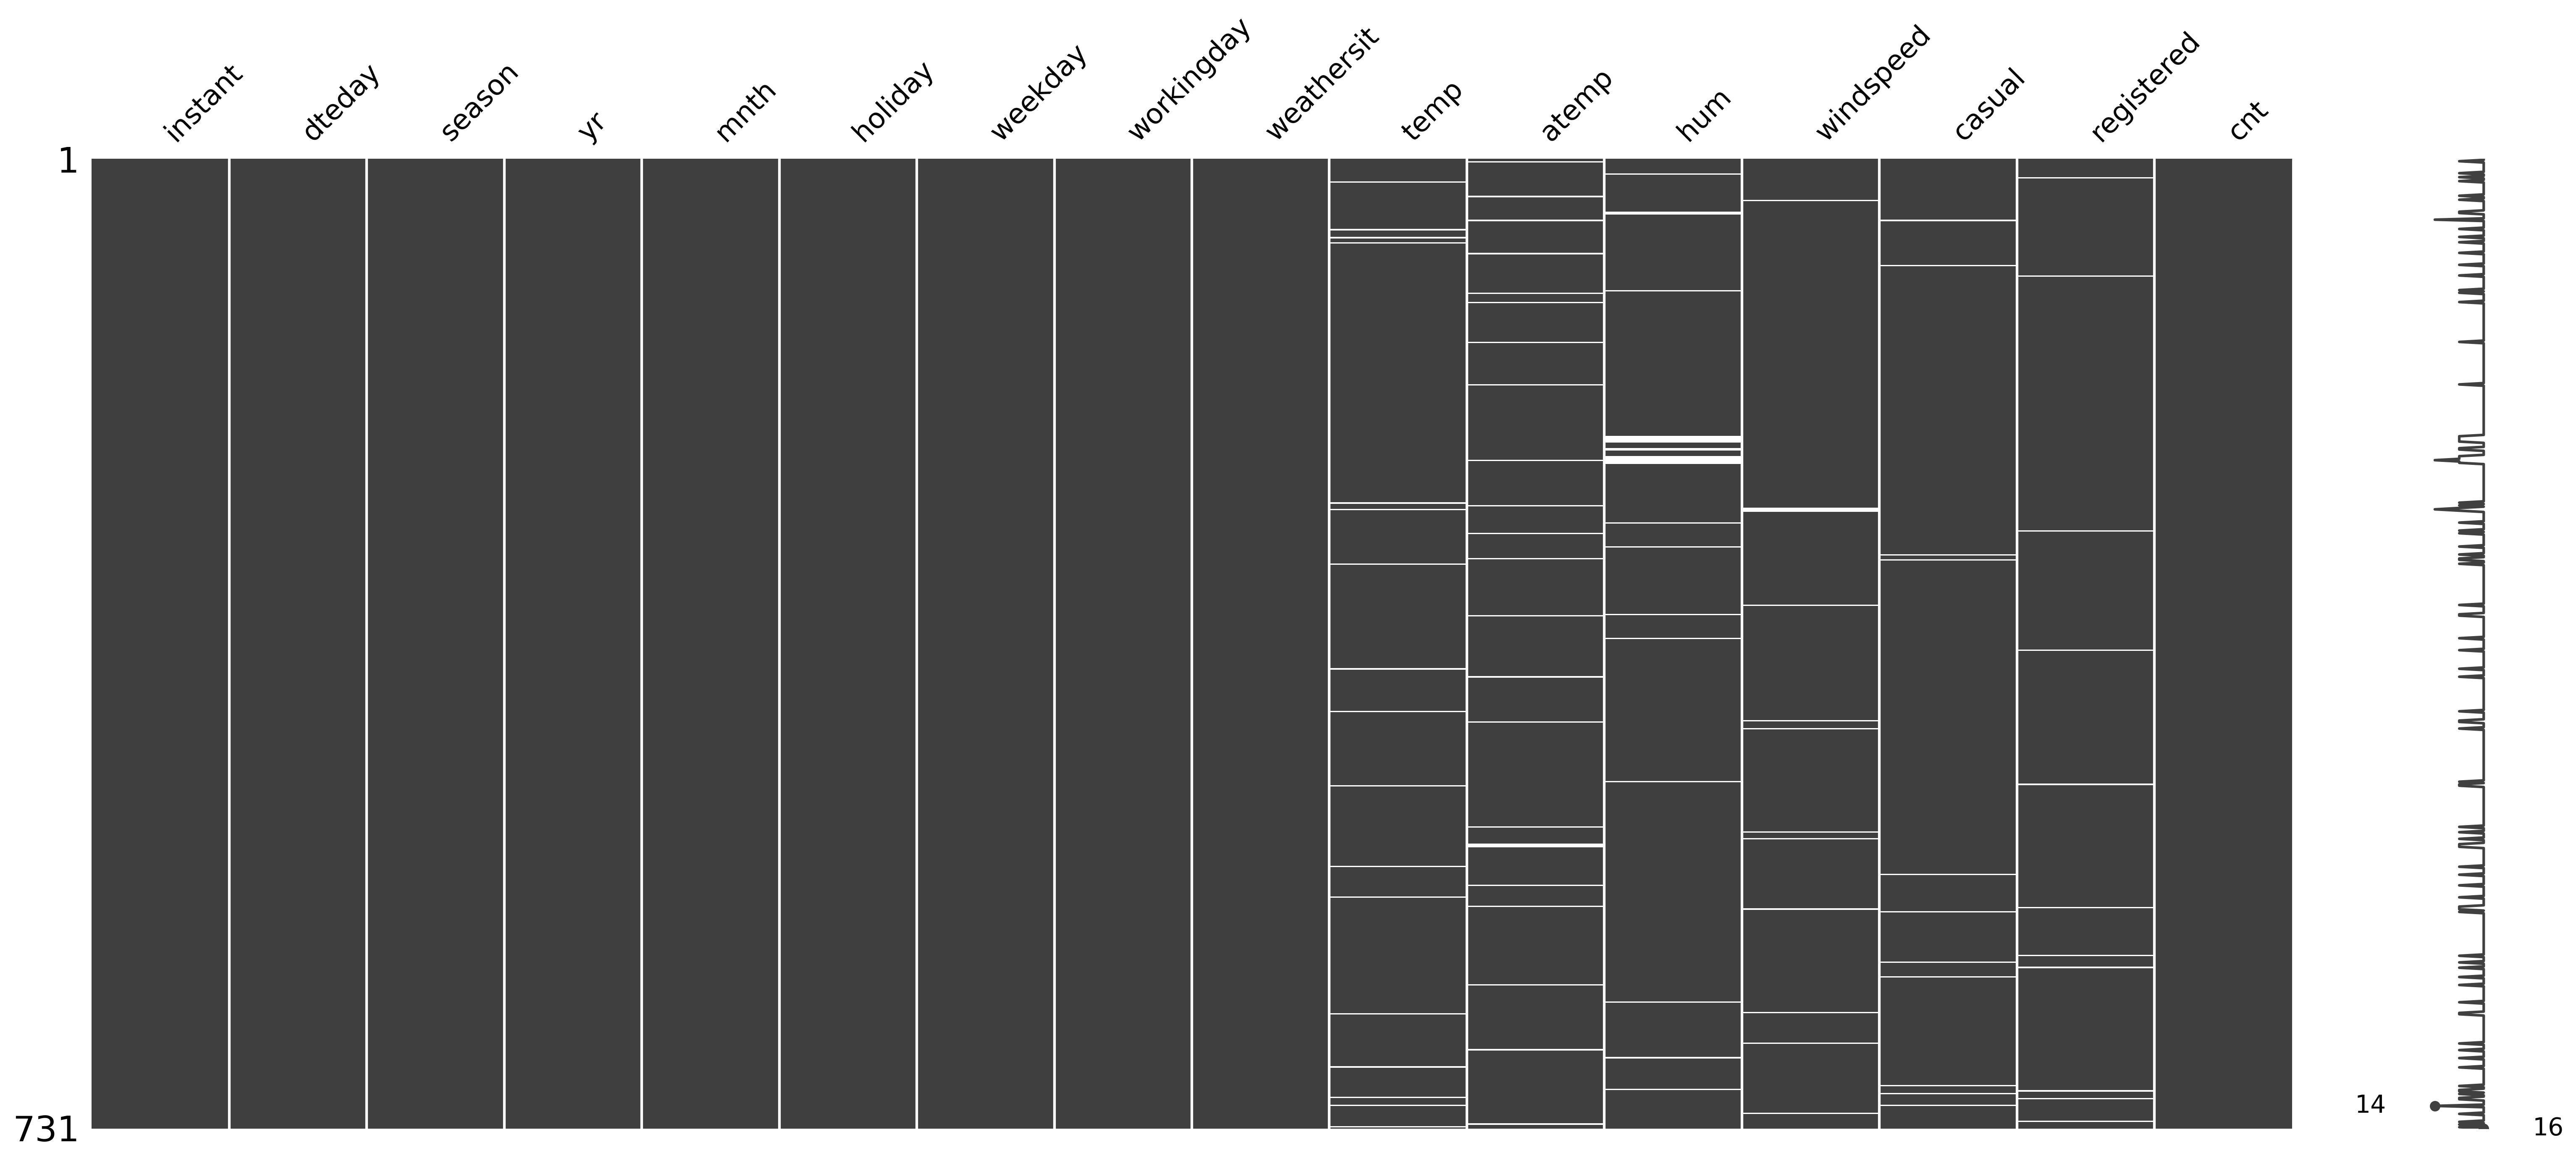

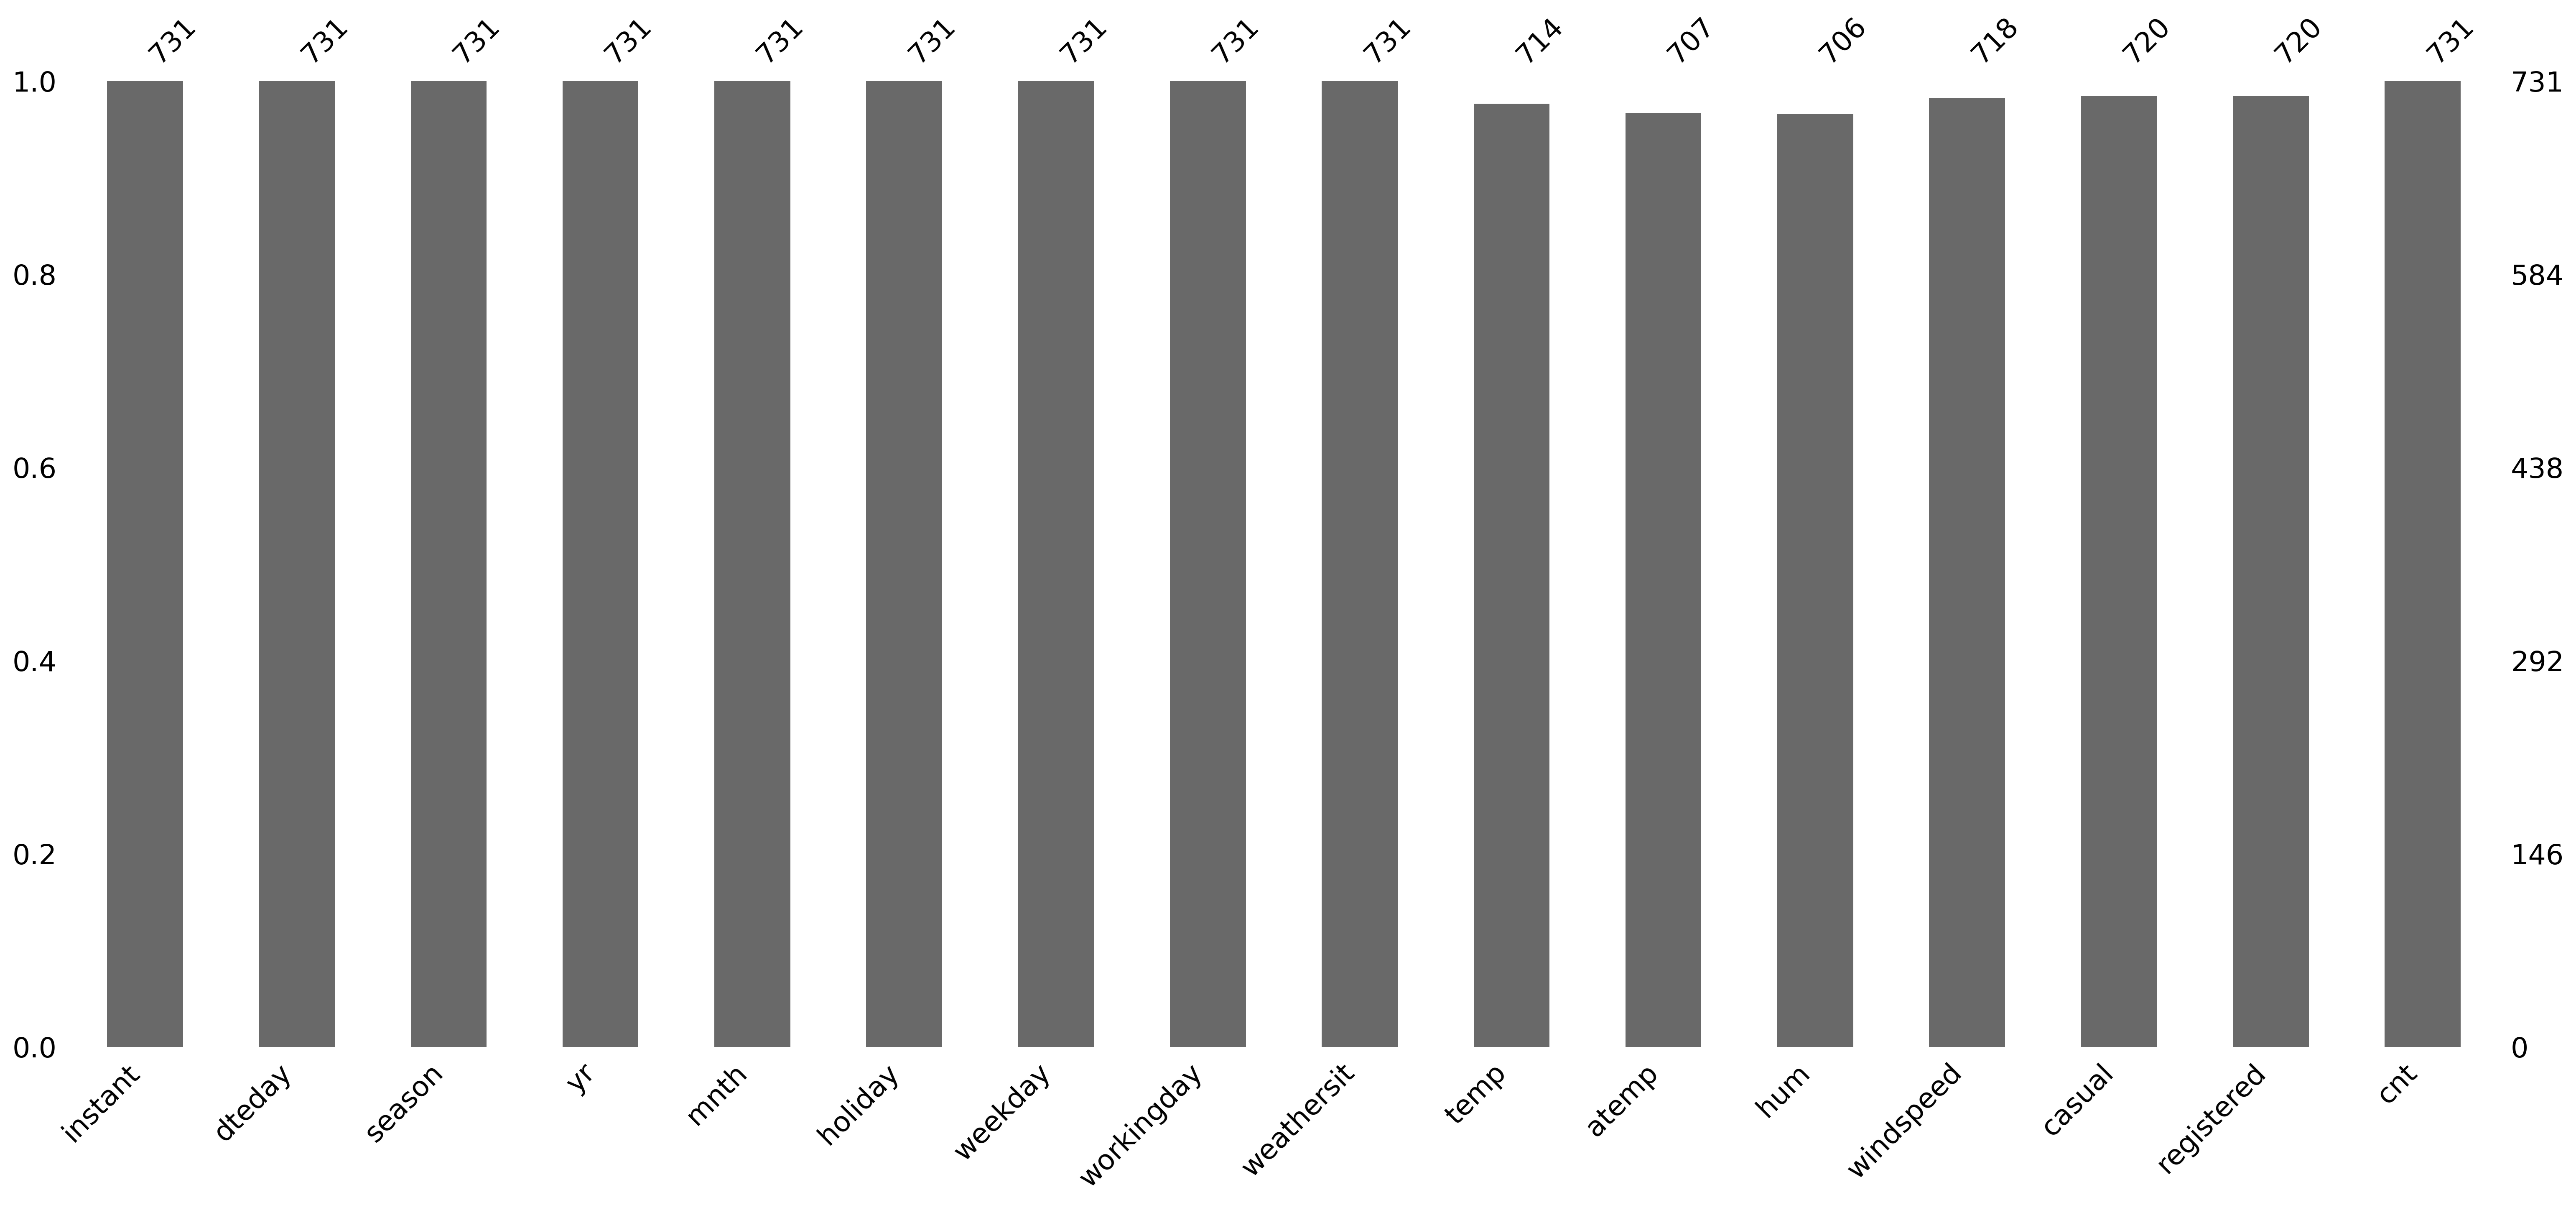

In [20]:
# 결측값 시각화 - 전체 컬럼의 결측값 시각화

msno.matrix(df)
# missingno의 matrix() 함수를 사용하여 결측값을 시각적으로 표시함  
# 각 열은 하나의 컬럼을 의미하며, 회색은 값이 존재함을, 흰색은 결측값이 있음을 나타냄  
# 데이터의 누락 패턴과 결측값 분포(연속성 포함)를 파악할 수 있음  
# 우측의 바는 각 행(row)의 데이터 존재 밀도를 보여줌  

plt.show()
# 위에서 설정한 matrix 시각화를 화면에 출력함  
# Jupyter 환경에서는 이 명령어를 통해 실제 시각화 결과가 나타남  

msno.bar(df)
# missingno의 bar() 함수를 사용하여 컬럼별 결측값 개수를 막대그래프로 시각화함  
# 각 컬럼별로 전체 행 수 대비 결측값이 얼마나 존재하는지를 비율로 확인할 수 있음  
# 결측값이 많은 컬럼을 빠르게 식별하는 데 유용함  

plt.show()
# 위에서 설정한 bar 시각화를 출력함  
# 막대의 길이와 수치를 통해 정량적으로 결측값 현황을 파악할 수 있음  

In [21]:
# 결측값이 아닌 빈 문자열이 있는지 확인

def is_emptystring(x):
    return x.eq('').any()
    # Series x에서 빈 문자열('')과 같은 값이 있는지를 판별함  
    # eq('')는 각 원소가 빈 문자열인지 여부를 논리형으로 반환함  
    # any()는 하나라도 True가 있을 경우 True를 반환함  
    # 즉, 해당 컬럼에 빈 문자열이 하나라도 존재하면 True를 반환함  

df.apply(lambda x: is_emptystring(x))
# 데이터프레임 df의 모든 컬럼에 대해 is_emptystring 함수를 적용함  
# 각 컬럼별로 빈 문자열 존재 여부를 확인하고, True/False 시리즈로 반환함  
# 결과적으로 빈 문자열이 포함된 컬럼을 식별하는 용도로 사용함  

# NaN(결측값)과 ''(빈 문자열)은 전혀 다른 것이며, 
# 지금 데이터프레임에는 빈 문자열이 아예 없기 때문에 결과가 모두 False인 것.

instant       False
dteday        False
season        False
yr            False
mnth          False
holiday       False
weekday       False
workingday    False
weathersit    False
temp          False
atemp         False
hum           False
windspeed     False
casual        False
registered    False
cnt           False
dtype: bool

In [22]:
# 결측값 표본 제거

df_drop_all = df.dropna(how='all')
# 모든 컬럼의 값이 전부 결측값인 행만 제거함  
# how='all'은 해당 행의 모든 값이 NaN인 경우에만 삭제 조건으로 인식함  
# 대부분의 컬럼이 존재하고 일부만 결측된 경우는 유지함  

df_drop_3 = df.dropna(thresh=3)
# 결측값이 3개 이상인 행을 제거하고, 3개 이상 값이 존재하는 행은 유지함  
# thresh는 "최소한 몇 개의 비결측값이 있어야 삭제하지 않을지"를 기준으로 설정함  
# 예: thresh=3이면 최소 3개 이상 값이 있어야 행이 유지됨  

df_drop_slt = df.dropna(subset=['temp'])
# 'temp' 컬럼에 결측값이 있는 행만 제거함  
# subset 파라미터를 통해 특정 컬럼 기준으로 결측값 제거 조건을 제한함  

df_drop_any = df.dropna(how='any')
# 하나라도 결측값이 존재하는 모든 행을 제거함  
# how='any'는 조건이 가장 강력하여 일부 값만 누락되어도 전체 행이 삭제됨  

df_drop_any.isnull().sum()
# dropna(how='any') 처리가 적용된 df_drop_any에서 남아 있는 결측값 개수를 컬럼별로 확인함  
# 출력 결과가 모두 0이면 모든 결측값이 완전히 제거되었음을 의미함  


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [23]:
# df.info()
df_drop_any.info()
# dropna(how='any')를 적용한 데이터프레임(df_drop_any)의 구조 정보를 출력함  
# 각 컬럼의 이름, 데이터 타입, 결측값 유무, 메모리 사용량 등을 요약하여 확인함  
# 결측값이 하나라도 있는 행이 모두 제거되었기 때문에, Non-Null count는 모든 컬럼에서 총 행 수와 동일해야 함  
# 전체 결측값이 제거된 후의 데이터 상태를 검증하는 용도로 사용함  


<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     634 non-null    int64  
 1   dteday      634 non-null    object 
 2   season      634 non-null    int64  
 3   yr          634 non-null    int64  
 4   mnth        634 non-null    int64  
 5   holiday     634 non-null    int64  
 6   weekday     634 non-null    int64  
 7   workingday  634 non-null    int64  
 8   weathersit  634 non-null    int64  
 9   temp        634 non-null    float64
 10  atemp       634 non-null    float64
 11  hum         634 non-null    float64
 12  windspeed   634 non-null    float64
 13  casual      634 non-null    float64
 14  registered  634 non-null    float64
 15  cnt         634 non-null    int64  
dtypes: float64(6), int64(9), object(1)
memory usage: 84.2+ KB


In [24]:
# 결측값 기본 대치 방법들

df_0_all = df.fillna(0)
# 전체 컬럼의 결측값을 숫자 0으로 대치함  
# 수치형 컬럼 외에 문자열 컬럼에도 0이 삽입되므로 컬럼 타입에 주의가 필요함  

df_0_slt = df.fillna({'temp': 0})
# 'temp' 컬럼의 결측값만 0으로 대치함  
# 다른 컬럼의 결측값은 그대로 유지함  

df_mean_all = df.fillna(df.mean(numeric_only=True))
# 전체 수치형 컬럼에 대해 평균값으로 결측값을 대치함  
# numeric_only=True를 통해 숫자형 컬럼만 대상으로 평균을 계산함  
# 문자열 등 비수치형 컬럼은 무시됨  

# df_mean_all = df.fillna(df.select_dtypes(include='number').mean())
# 위와 동일한 동작을 명시적으로 수치형 컬럼만 선택하여 수행하는 대안 코드임  

df_mean_slt = df.fillna({'temp': df['temp'].mean()})
# 'temp' 컬럼의 결측값만 해당 컬럼의 평균값으로 대치함  

df_median_all = df.fillna(df.median(numeric_only=True))
# 전체 수치형 컬럼의 결측값을 중앙값으로 대치함  
# 중앙값은 이상치에 덜 민감하므로 안정적인 대치 방법임  

df_median_slt = df.fillna({'temp': df['temp'].median()})
# 'temp' 컬럼만 중앙값으로 결측값을 대치함  

df_mode_all = df.fillna(df.mode())
# 전체 컬럼에 대해 최빈값으로 결측값을 대치함  
# mode()는 여러 개의 최빈값이 있을 경우 첫 번째 값을 사용함  

df_mode_slt = df.fillna({'temp': df['temp'].mode()})
# 'temp' 컬럼의 결측값을 최빈값으로 대치함  
# 주의: df['temp'].mode()는 Series이므로 단일 값이 아닌 경우에는 오류 발생 가능성 있음  

df_max_all = df.fillna(df.max())
# 전체 컬럼의 결측값을 해당 컬럼의 최댓값으로 대치함  
# 통계적으로는 특수한 목적이 없으면 권장되지 않음  

df_max_slt = df.fillna({'temp': df['temp'].max()})
# 'temp' 컬럼만 최댓값으로 결측값을 대치함  

df_min_all = df.fillna(df.min())
# 전체 컬럼의 결측값을 해당 컬럼의 최솟값으로 대치함  

df_min_slt = df.fillna({'temp': df['temp'], 'hum': df['hum'].min()})
# 'temp' 컬럼은 기존 값으로 유지하고, 'hum' 컬럼의 결측값만 최솟값으로 대치함  

df_min_slt.isnull().sum()
# 최솟값 대치 이후 결측값이 남아 있는 컬럼을 확인함  
# 모든 컬럼의 결측값이 잘 대치되었는지를 검증하는 절차임  


instant        0
dteday         0
season         0
yr             0
mnth           0
holiday        0
weekday        0
workingday     0
weathersit     0
temp          17
atemp         24
hum            0
windspeed     13
casual        11
registered    11
cnt            0
dtype: int64

In [25]:
# 결측값 보간 대치 방법들

df1 = df.copy()
# 원본 데이터를 보존하기 위해 df를 복사하여 df1이라는 새로운 데이터프레임을 생성함

df1['temp'].fillna(method='pad', inplace=True)
# 'temp' 컬럼의 결측값을 바로 이전 시점의 값으로 대치함 (forward fill 방식)
# method='pad'는 결측값 발생 시 이전 유효값을 복사하여 채움
# inplace=True는 해당 컬럼에 직접 적용함

# 예시: [10, NaN, NaN, 20] → [10, 10, 10, 20]

df_bfill_all = df.fillna(method='bfill')
# 전체 컬럼에 대해 다음 시점의 값으로 결측값을 대치함 (backward fill 방식)
# 결측값 발생 시 이후에 등장하는 가장 가까운 유효값을 복사하여 채움

# 예시: [10, NaN, NaN, 20] → [10, 20, 20, 20]

df_bfill_limit = df.fillna(method='bfill', limit=1)
# backward fill을 수행하되, 연속 결측값 중 최대 1개까지만 다음 값으로 채움
# limit=1은 연속된 NaN 중 첫 번째만 채우고 나머지는 유지함

# 예시: [10, NaN, NaN, 20] → [10, 20, NaN, 20]

ts_intp_linear = df.interpolate(method='values')
# 선형 보간법을 사용하여 결측값을 앞뒤 값의 평균을 기반으로 순차적으로 채움
# method='values'는 인덱스를 고려하지 않고 값의 순서에 따라 보간을 수행함

# 예시: [10, NaN, NaN, 16] → [10, 12, 14, 16]

df['dteday'] = pd.to_datetime(df['dteday'])
# 'dteday' 컬럼을 문자열에서 datetime 형식으로 변환함
# 시간 기반 보간을 위해 시계열 인덱스가 필요하므로 사전 처리 단계임

df_i = df.set_index('dteday')
# 'dteday' 컬럼을 인덱스로 설정하여 시간 축 기준의 보간이 가능하도록 만듦

df_time = df_i.interpolate(method='time')
# 시간 인덱스를 기준으로 시간 기반 보간법을 적용함
# 값 간 시간 간격의 상대적 거리(예: 하루 vs 일주일)를 고려하여 결측값을 선형적으로 채움

df_time.isnull().sum()
# 보간이 적용된 결과에서 여전히 남아 있는 결측값의 개수를 컬럼별로 확인함
# 연속된 NaN이 너무 많거나 첫/끝 위치에 있는 경우 보간이 되지 않을 수 있음


/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_5037/1504156925.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['temp'].fillna(method='pad', inplace=True)
/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_5037/1504156925.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df1['temp'].fillna(method='pad', inplace=True)
/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_5037/1504156925.py:13: FutureWarning

instant       0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [26]:
#다중 대치(MICE) 

# dteday 컬럼 제거
df_dp = df.drop(['dteday'], axis=1)
# 다중 대치 적용 전, datetime 형식의 'dteday' 컬럼을 제거함
# IterativeImputer는 수치형 데이터만 처리 가능하므로 시계열 정보는 제거 대상이 됨
# axis=1은 열 단위 제거를 의미함

# ======================================================================================
# 💡 다중 대치 (Multiple Imputation by Chained Equations, MICE)의 핵심 개념 설명

# ✅ 목적:
# - 단순히 평균이나 중앙값으로 결측값을 채우는 것이 아닌,
#   데이터의 변수 간 관계(패턴)를 바탕으로 **결측값을 예측하여 채움**.

# ✅ 동작 방식 요약:
# 1. 먼저, 모든 결측값을 일시적으로 평균 등으로 초기 대치함 (임시 채움)
# 2. 그런 다음, 결측값이 있는 **한 변수씩** 돌아가면서
#    - 해당 변수를 타겟 변수로 두고
#    - 나머지 변수들을 입력 변수로 설정하여
#    - **회귀 모델을 학습**함 (예: 선형 회귀, 랜덤 포레스트 등 내부에서 자동 선택)
# 3. 학습된 모델로 현재 변수의 결측값을 다시 예측하여 갱신함
# 4. 이 과정을 모든 결측 컬럼에 대해 반복하며, 전체 과정을 여러 번 반복함 (수렴할 때까지)
# 5. 최종적으로, 예측된 값들을 이용해 결측값을 대치한 데이터셋을 생성함

# ✅ 장점:
# - 변수 간의 복잡한 상관관계를 반영할 수 있음
# - 단순 평균/중앙값보다 통계적 왜곡이 훨씬 적음
# - 예측 기반이라 더 정교한 대치 가능

# ✅ 예시 비유:
# - "나이"가 결측된 행에 대해 "수입", "직업", "교육 수준"을 보고 나이를 예측한다고 생각하면 됨
# - 그리고 "수입"이 결측된 행은 "나이", "직업", "교육 수준"을 보고 다시 예측함
# - 이런 식으로 예측 모델을 서로 번갈아 학습하며 결측값을 보완해 나가는 구조임

# ✅ 파라미터 이해:
# - imputation_order: 어떤 변수부터 대치할지를 정함 (보통 'ascending': 결측 적은 순으로)
# - max_iter: 전체 반복 횟수 (보통 10회 이상이면 충분히 수렴)
# - random_state: 재현 가능성을 위한 난수 고정
# - n_nearest_features: 대치 시 사용할 인접 피처 수 제한 (전체 변수 중 영향력 높은 것만 사용하도록 제어)

# ✅ 사용 시 주의:
# - 수치형 데이터에만 적용 가능함
# - 문자형, datetime 등은 제거하거나 전처리 필요
# - 컬럼 수가 너무 많으면 연산 비용이 커지므로 n_nearest_features로 제한하는 것이 좋음
# ======================================================================================


# 다중 대치 알고리즘 설정
imputer = IterativeImputer(
    imputation_order='ascending',
    # 결측값이 적은 변수부터 먼저 대치하는 방식으로 학습 순서를 설정함
    # 초기 대치값이 더 안정적으로 설정될 수 있도록 순서를 조절함

    max_iter=10,
    # 전체 결측값 대치 과정을 최대 10회 반복 수행함
    # 반복 횟수가 많을수록 수렴 정확도는 높아지나 계산량이 증가함

    random_state=42,
    # 대치 과정에 포함된 랜덤 요소를 고정하여 결과 재현성을 확보함

    n_nearest_features=5
    # 결측값 예측 시 사용할 주변 피처(변수)의 수를 최대 5개로 제한함
    # 성능 최적화를 위해 전체 피처를 모두 사용하지 않고 일부만 선택함
)
# IterativeImputer는 MICE(Multivariate Imputation by Chained Equations) 기반 알고리즘임
# 각 변수에 대해 다른 변수들을 입력으로 하는 회귀 모델을 반복 학습하며 결측값을 예측함

# 다중 대치 적용
df_imputed = imputer.fit_transform(df_dp)
# IterativeImputer 객체를 사용하여 결측값이 있는 데이터프레임(df_dp)에 대해 다중 대치(MICE)를 수행함  
# 각 컬럼의 결측값을 다른 컬럼의 값을 기반으로 회귀 방식으로 예측하여 반복적으로 보완함  
# 결과는 numpy 배열 형태로 반환되며, 결측값이 모두 채워진 상태임  

# 판다스 변환 및 컬럼 설정
df_imputed = pd.DataFrame(df_imputed)
# numpy 배열로 반환된 대치 결과를 다시 pandas DataFrame으로 변환함  

df_imputed.columns = ['instant','season','yr','mnth','holiday',
                      'weekday','workingday','weathersit','temp',
                      'atemp','hum','windspeed','casual','registered','cnt']
# 원본 데이터와 동일한 컬럼명을 부여하여 해석 가능성과 일관성을 확보함  


df_imputed.isnull().sum()
# 다중 대치가 성공적으로 수행되었는지 검증하기 위해 결측값이 남아 있는지 확인함  
# 모든 컬럼에서 0이 출력되면 결측값이 완전히 제거되었음을 의미함  


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


instant       0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### ✅ **기본 `IterativeImputer`는 카테고리컬 데이터에 직접 사용하기 어려움.**

### 이유:

- `IterativeImputer`는 **회귀 기반(연속형 변수 예측)** 모델을 내부적으로 사용.
- 즉, 결측값이 있는 컬럼을 **연속값(실수)** 으로 예측하려 하기 때문에,
    
    **범주형 데이터(예: 'season'=1,2,3,4)** 가 들어가면:
    
    - 예: 2.48 같은 비정수값이 나올 수 있음
    - 범주형 값의 의미가 깨짐 (예: 요일이 2.6일 수는 없음)

---

### 🔧 그렇다면 범주형 변수는 어떻게 처리하나요?

### ✅ 1. **사전 인코딩 + 후처리 필요**

```python
# 예시: 범주형 변수 'season' (1,2,3,4)을 예측할 경우

# ➤ 대치 후 결과: 2.74
# ➤ 처리 방식: np.round(2.74) → 3
# 또는 범주 중 가장 가까운 값 선택

# ➤ 범주형 컬럼은 다음처럼 다뤄야 함:
- 대치 전: 숫자 범주(정수)로 변환 (LabelEncoding)
- 대치 후: 다시 정수로 반올림 또는 재매핑

```

### ✅ 2. **연속형과 범주형을 분리해서 처리**

- 수치형 → `IterativeImputer`
- 범주형 → `SimpleImputer(strategy='most_frequent')` 또는 `KNNImputer` + 라운딩

### ✅ 3. **대안 모델 사용**

- `fancyimpute`의 `IterativeImputer` (sklearn 외 라이브러리)
- `Datawig`, `MissForest` 등 **범주형 지원하는 결측 대치 모델** 사용

---

### ✅ 정리

| 항목 | 가능 여부 | 설명 |
| --- | --- | --- |
| 연속형 데이터 (float, int) | ✅ 가능 | `IterativeImputer`의 기본 대상 |
| 정수형 범주 데이터 | ⚠️ 가능하나 후처리 필요 | 예측값을 `round()` 하거나 `mode` 재매핑 필요 |
| 문자열 범주 데이터 | ❌ 불가능 | 직접 사용 시 오류 발생 (숫자 인코딩 필요) |